In [1]:
import numpy as np
import scipy as sc
import scipy.stats as sts
import matplotlib.pyplot as plt
%matplotlib inline

# Гречишкин Денис ПМ-31

# Лабораторная работа №6

# Часть 6.4 (Примеры для совместного обсуждения)

## Пример 1

Text(0, 0.5, 'alpha_2')

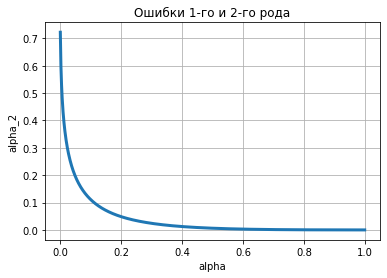

In [2]:
n = 25
m0 = 10
m1 = 11
sigma = 2
alpha = np.linspace(0.001, 0.999, 1000)
alpha2 = sts.norm(m1, sigma/np.sqrt(n)).cdf(sts.norm(0, 1).ppf(1 - alpha)*sigma/np.sqrt(n) + m0)
plt.plot(alpha, alpha2, lw = 3)
plt.grid(True)
plt.title('Ошибки 1-го и 2-го рода')
plt.xlabel('alpha')
plt.ylabel('alpha_2')

## Пример 2

Text(0, 0.5, 'alpha_2')

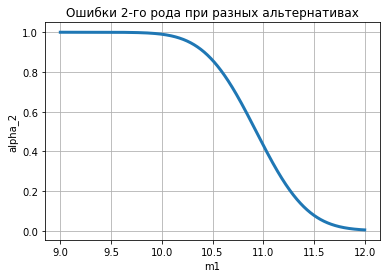

In [3]:
n = 25
m0 = 10
alpha = 0.01
sigma = 2
m1 = np.linspace(9, 12, 1000)
alpha2 = sts.norm(m1, sigma/np.sqrt(n)).cdf(sts.norm(0, 1).ppf(1 - alpha) * sigma / np.sqrt(n) + m0)
plt.plot(m1, alpha2, lw = 3)
plt.grid(True)
plt.title('Ошибки 2-го рода при разных альтернативах')
plt.xlabel('m1')
plt.ylabel('alpha_2')

## Пример 3

Text(0, 0.5, 'alpha_2')

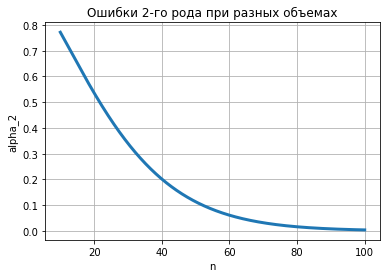

In [4]:
m0 = 10
m1 = 11
alpha = 0.01
sigma = 2
n = np.linspace(10, 100, 1000)
alpha2 = sts.norm(m1, sigma/np.sqrt(n)).cdf(sts.norm(0, 1).ppf(1 - alpha) * sigma / np.sqrt(n) + m0)
plt.plot(n, alpha2, lw = 3)
plt.grid(True)
plt.title('Ошибки 2-го рода при разных объемах')
plt.xlabel('n')
plt.ylabel('alpha_2')

# Часть 6.5.(Задания для самостоятельного выполнения)

## Задание 1: Смоделируйте выборку объема n = 100 из нормально распределенной генеральной совокупности с параметрами $m_0, \sigma_0$ (значения параметров $m_0, \sigma_0$ возьмите равными длине вашего имени и фамилии соответственно) и далее используйте ее в качестве опытных данных. 
Задача состоит в проверке гипотезы $H_0: m = m_0$ при неизвестной дисперсии. Сформулируйте двустороннюю альтернативу, выберите статистику, укажите ее закон распределения. Вычислите p – значение и найдите диапазон значений, при которых основная гипотеза принимается. Задание выполните двумя способами: без использования имеющейся в языке программирования Python функции проверки параметрических гипотез и воспользовавшись функцией ttest_1samp. Сопоставьте полученные результаты.

## Решение: Значения $m_0 = 5, \sigma_0 = 9$. $\newline$ Двусторонняя альтернатива: $H_1: m \neq m_0$.  1-й способ: сначала составим выборку объема 100 и найдем выборочное мат ожидание и дисперсию

In [5]:
m0 = 5
sigma0 = 9
n = 100
selection = np.random.normal(m0, sigma0, n)
m_sel = np.sum(selection)/n
d_sel = 0
for el in selection:
    d_sel += (el - m_sel)**2
d_sel /= (n - 1)
d_sel = np.sqrt(d_sel)

Выберем уровень значимости. Так как мы проверяем гипотезу $H_0: m = m_0$ и дисперсия неизвестна, то нам подойдет статистика $W = \frac{\overline{X} -  m_0}{S / \sqrt{n}} \sim St(n - 1) \newline$ 
Теперь найдем критическую область. Т.к альтернатива двусторонняя то $G_{\alpha} = (W < t_{\frac{\alpha}{2}}(n-1)) \bigcup (W > t_{1 - \frac{\alpha}{2}}(n - 1)) = (W < t_{\frac{\alpha}{2}}(99)) \bigcup (W > t_{1 - \frac{\alpha}{2}}(99)) \newline$
Найдем выборочное значение этой статистики и построим график зависимости от уровня значимости

гипотеза верна при уровне значимости alpha меньше либо равном 0.9486357684507803


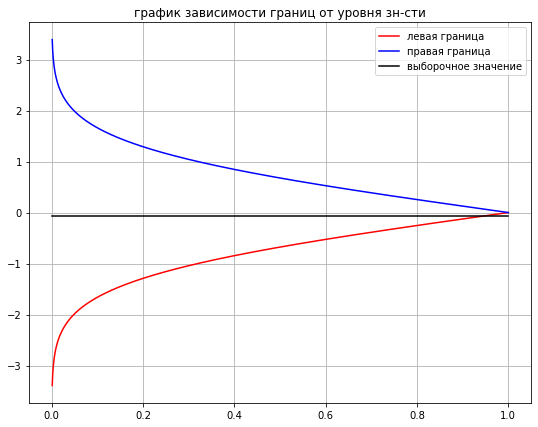

In [6]:
alpha = np.linspace(0, 1, 1000)
#print(alphas)
#flag = False
w_sel = (m_sel - m0)/(d_sel/np.sqrt(n))
#print(w_sel)
plt.figure(figsize = (9, 7))
t1 = (sts.t(n - 1)).ppf(alpha/2)
t2 = (sts.t(n - 1)).ppf(1 - alpha/2)
plt.plot(alpha, t1, '-r', label = 'левая граница')
plt.plot(alpha, t2, '-b', label = 'правая граница')
plt.plot(alpha, w_sel*alpha**0, '-k', label = 'выборочное значение')
plt.grid(True)
plt.title('график зависимости границ от уровня зн-сти')
plt.legend()


p_teor = sts.t(n - 1).cdf(w_sel)
p_teor = 2*min(p_teor, 1 - p_teor)
print('гипотеза верна при уровне значимости alpha меньше либо равном', p_teor)

2-й способ: Найдем выборочное значение функции с помощью функции ttest_1samp и проделаем всё то-же самое что и в 1-м пункте

In [7]:
w_sel = sts.ttest_1samp(selection, m0, axis = 0, nan_policy = 'propagate')
#print(w_sel)
print('Выборочное значение статистики W:', w_sel[0])
print('Достигаемый уровень значимости:', w_sel[1])

Выборочное значение статистики W: -0.06458360575962847
Достигаемый уровень значимости: 0.9486357684507803


Достигаемый уровень значимости $\newline$
Теоретически: 0.683300563105552$\newline$
С помощью функции 0.683300563105552$\newline$

## Задание 2: Смоделируйте выборку объема n = 90 из нормально распределенной генеральной совокупности с параметрами $m_0, \sigma_0$  (значения параметров $m_0, \sigma_0$ возьмите равными длине вашего имени и фамилии соответственно) и далее используйте ее в качестве опытных данных. Задача состоит в проверке гипотезы $H_0: \sigma = \sigma_0$ при неизвестном математическом ожидании. Исходя из значения выборочной дисперсии, сформулируйте подходящую одностороннюю альтернативу, выберите статистику и укажите закон ее распределения. 
1) Не используя имеющиеся в языке программирования Python функции проверки параметрических гипотез, вычислите p-значение и найдите диапазон значений $\alpha$ , при которых основная гипотеза принимается. 
2) Выберите одно из значений $\alpha$ из найденного диапазона и, исходя из соответствующей этому значению критической области (согласно традиционной методике), вычислите ошибку второго рода (предварительно получив аналитическое выражение).

## Решение: Значения $m_0 = 5, \sigma_0 = 9$. $\newline$ Односторонняя альтернатива $H_1:\sigma \lt \sigma_0$. 

Так как мы проверяем гипотезу $H_0: \sigma = \sigma_0$ и мат ожидание неизвестно, то нам подойдет статистика $V_2 = \frac{S^2}{(\sigma_0)^2 / (n - 1)} \sim \chi^2(n - 1) \newline$ 

Найдем граничную область: Т.к альтернатива - левосторонняя то критическая область $G_{\alpha} = (V_2 < \chi_{\alpha}(n-1))$

## Пункт 1: составим выборку нормального распределения, найдем выборочное мат ожидание и выборочную дисперсию и найдем выборочное значение статистики

In [42]:
m0 = 5
sigma0 = 9
n = 90
selection = np.random.normal(m0, sigma0, n)
m_sel = np.sum(selection)/n
d_sel = 0
for el in selection:
    d_sel += (el - m_sel)**2
d_sel /= (n - 1)
print(d_sel)

74.98786089084422


гипотеза верна при уровне значимости alpha меньше либо равном 0.3236077093730105


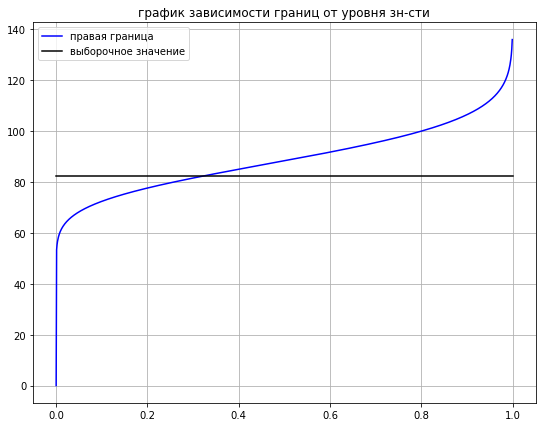

In [43]:
alpha = np.linspace(0, 1, 1000)
#print(alphas)
#flag = False
w_sel = d_sel/(sigma0**2/(n - 1))
#print(w_sel)
plt.figure(figsize = (9, 7))
chi = (sts.chi2(n - 1)).ppf(alpha)

plt.plot(alpha, chi, '-b', label = 'правая граница')
plt.plot(alpha, w_sel*alpha**0, '-k', label = 'выборочное значение')
plt.grid(True)
plt.title('график зависимости границ от уровня зн-сти')
plt.legend()

p_teor = sts.chi2(n - 1).cdf(w_sel)
#p_teor = 2*min(p_teor, 1 - p_teor)
print('гипотеза верна при уровне значимости alpha меньше либо равном', p_teor)

## Пункт 2: возьмем значение $\alpha = 0.9$ и $\sigma_1 = 8$. Для него ошибка второго рода:
$$\alpha_2=P \left \{ \frac{S^2}{(\sigma_0)^2 / (n - 1)} \le \chi^2_{1 - \alpha}(n - 1) \lvert X_i \sim N(m_0, \sigma_1) \right \} = P \left \{ S^2 \le \frac{\chi^2_{1 - \alpha}(n - 1) \cdot (\sigma_0)^2 }{n-1}\lvert X_i \sim N(m_0, \sigma_1) \right \}$$
Найдем мат. ожидание и дисперсию оценки $S^2$:$\newline$
Мат. ожидание:
$$S^2 = \frac{n}{n - 1}D^* = \frac{n}{n - 1} \frac{1}{n} \sum_{i = 1}^n (X_i - \overline X)^2 = \frac{n}{n - 1} \frac{1}{n} \sum_{i = 1}^n (X_i - \overline X)^2 = \frac{n}{n - 1} \frac{1}{n} \sum_{i = 1}^n ((X_i - m_0) - (\overline X - m_0))^2 = \frac{1}{n - 1}\sum_{i = 1}^n (X_i - m_0)^2 + \frac{2}{n - 1}\sum_{i = 1}^n (X_i\overline X - m_0\overline X - m_0X_i + m_0^2) + \frac{1}{n - 1}\sum_{i = 1}^n (\overline X - m_0)^2 = \frac{1}{n - 1}\sum_{i = 1}^n (X_i - m_0)^2 + \frac{2}{n - 1}(\overline X\sum_{i = 1}^n X_i - nm_0\overline X - m_0\sum_{i = 1}^nX_i + nm_0^2) + \frac{1}{n - 1}\sum_{i = 1}^n (\overline X - m_0)^2 = \frac{1}{n - 1}\sum_{i = 1}^n (X_i - m_0)^2 - 2(\overline X - m_0)^2 + (\overline X - m_0)^2 = \frac{1}{n - 1}\sum_{i = 1}^n (X_i - m_0)^2 - (\overline X - m_0)^2$$

$$M[S^2] = M[\frac{1}{n - 1}\sum_{i = 1}^n (X_i - m_0)^2 - (\overline X - m_0)^2] = \frac{1}{n - 1}\sum_{i = 1}^n M[(X_i - m_0)^2] - M[(\overline X - m_0)^2] = D[X] = \sigma_1^2 = 64$$
Дисперсия:
$$D[S^2] = D[\frac{1}{n - 1} \sum_{i = 1}^n (X_i - \overline X)^2] = \frac{\sigma_1^2}{n - 1} = \frac{64}{89}$$

Тогда ошибка второго рода:
$$\alpha_2 = P \left \{ S^2 \le \frac{\chi^2_{1 - \alpha}(n - 1) \cdot (\sigma_0)^2 }{n-1}\lvert X_i \sim N(m_0, \sigma_1) \right \} = F_{S^2}(\frac{\chi^2_{1 - \alpha}(n - 1) \cdot (\sigma_0)^2 }{n-1})$$

In [44]:
Alpha = 0.9
sigma1 = 8
Chi = (sts.chi2(n - 1)).ppf(1 - Alpha)
alpha2 = 1 - (sts.norm(64, 8/(np.sqrt(89)))).cdf((Chi*sigma0**2)/(n - 1))
print('Ошибка второго рода при уровне значимости', Alpha, ':', alpha2)

Ошибка второго рода при уровне значимости 0.9 : 0.013292686563506462


## Задание 3: Пусть проверяется гипотеза $H_0: m = m_0$ ($m_0$ – длина вашего имени) на уровне значимости $\alpha = 0,05$ при альтернативной гипотезе $H_1: m \gt m_0$ в предположении, что среднее квадратичное отклонение известно и равно длине вашей фамилии). Рассмотрим три случая: $\newline$ а) используется выборка объема n = 30; $\newline$ б) используется выборка объема n = 60; $\newline$ в) используется выборка объема n = 120. $\newline$
Для каждого случая укажите критическую область проверки гипотезы. Найдите функцию мощности критерия и постройте ее график (диапазон значений m нужно взять таким, чтобы адекватно представить множество возможных значений функции мощности). 
Ответьте на вопросы: как функция мощности связана с ошибками второго рода? первого рода?

## Решение: Значения $m_0 = 5, \sigma = 9, \alpha = 0,05$. 

пункт а): n = 30 
1) $H_0: m = m_0$, $H_1: m \gt m_0$
2) $\alpha = 0,05$ 
3) Т.к. мы рассматриваем гипотезу про мат ожидания при известной дисперсии, то нам подойдет статистика $\newline$
$U = \frac{\overline X - m_0}{\sigma/\sqrt{n}} \sim N(0, 1)$
4) Т.к альтернатива - левосторонняя то критическая область $G_{\alpha} = (U > u_{1 - \alpha})$ $\newline$
Найдем из п.4 критическую область(т.к критическая область не зависит от количества элементов в выборке, то оно будет одинаково)

In [11]:
alpha = 0.05
m0 = 5
sigma = 9
n = 30

u1 = (sts.norm(0, 1)).ppf(1 - alpha)
print('Критическая область: G_alpha = {U > ', u1, '}')

Критическая область: G_alpha = {U >  1.6448536269514722 }


Теперь найдем функцию мощности критерия, учитывая что $\overline X \sim N(m_0, \sigma/\sqrt{n})$ и при альтернативных гипотезах функция мощности критерия совпадает с ошибкой второго рода:

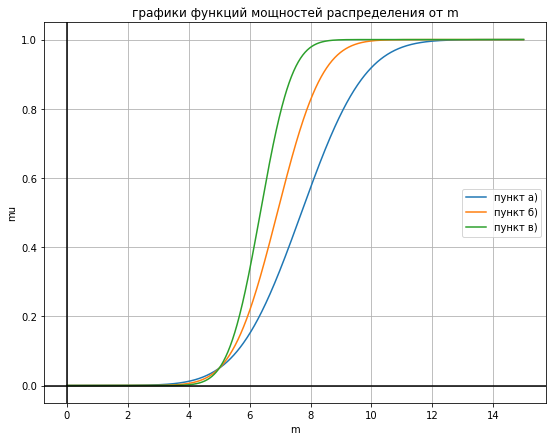

In [12]:
m = np.linspace(0, 15, 1000)
u_znach = sts.norm(0, 1).ppf(1 - alpha)
n1 = 30
n2 = 60
n3 = 120
mu1 = 1 - (sts.norm(m, sigma/np.sqrt(n1))).cdf(m0 + (u_znach*sigma)/np.sqrt(n1))
mu2 = 1 - (sts.norm(m, sigma/np.sqrt(n2))).cdf(m0 + (u_znach*sigma)/np.sqrt(n2))
mu3 = 1 - (sts.norm(m, sigma/np.sqrt(n3))).cdf(m0 + (u_znach*sigma)/np.sqrt(n3))
plt.figure(figsize = (9 ,7))
plt.plot(m, mu1, label = 'пункт а)')
plt.plot(m, mu2, label = 'пункт б)')
plt.plot(m, mu3, label = 'пункт в)')
plt.grid(True)
plt.title('графики функций мощностей распределения от m')
plt.axvline(x = 0, color = 'k')
plt.axhline(y = 0, color = 'k')
plt.xlabel('m')
plt.ylabel('mu')
plt.legend()

При прямой гипотезе $H_0: m = m_0$, функция мощности совпадает с ошибкой первого рода: $\mu(V_{кр}, m_0) = \alpha$. $\newline$
При альтернативной гипотезе $H_1: m = m_1$ значение функции мощности при $m = m_1$ связано с ошибкой второго рода следующим образом: $\mu(V_{кр}, m_0) = 1 - \beta$

## Задание 4: В урне содержатся неразличимые на ощупь черные и белые шары. Предполагается, что число черных и белых шаров в урне 
одинаково. Эта гипотеза принимается, если при извлечении 50 шаров (с возвращением) число черных шаров будет в пределах от 20 до 30. 
1) Сформулируйте основную гипотезу, укажите статистику и критическую область критерия. 
2) Опишите, в чем состоит ошибка первого рода, и вычислите ее вероятность. 
3) Найдите аналитическое выражение зависимости вероятности ошибки второго рода от альтернативных значений доли черных шаров в выборке и постройте ее график.

## Решение

## Пункт 1: Пусть X - индикатор того что извлекли черный шар, p – вероятность извлечения из урны черного шара; $X \sim I(p)$. Тогда основная гипотеза, заключающаяся в том что число белых шаров и число черных шаров одинаково, будет выглядеть следующим образом: $H_0: p = 0.5$. $\newline$
Тогда нам подойдет статистика: $Z = \frac{p^* - p_0}{\sqrt{p_0q_0/n}} \approx N(0, 1)$, где $p^* = \frac{1}{n}\sum_{i = 1}^{n} X_i$ $\newline$
Для того чтобы найти критическую область критерия, найдем его допустимую область:$\newline$
$n_1 = 20: p^* = \frac{20}{50} = 0.4; Z = \frac{0.4 - 0.5}{\sqrt{0.25/n}} = -0.2\sqrt{n}$ $\newline$
$n_2 = 30: p^* = \frac{30}{50} = 0.6; Z = \frac{0.6 - 0.5}{\sqrt{0.25/n}} = 0.2\sqrt{n}$ $\newline$
Получаем что доверительная область для гипотезы $H_0: G_{1 - \alpha} = (Z \in [-0.2\sqrt{n}; 0.2\sqrt{n}])$ $\newline$
Тогда критическая область $G_{\alpha} = (Z \in (-\infty; -0.2\sqrt{n})\cup(0.2\sqrt{n}; \infty))$

## Пункт 2: В данном эксперименте ошибка первого рода заключается в том что гипотеза $H_0$ принимается, но при извлечении 50 шаров, число черных шаров не оказалось в пределах от 20 до 30.$\newline$
Вероятность ошибки первого рода:
$$\alpha_2 = P(Z \notin G_{1 - alpha} | H_0) = P(Z \notin [-0.2\sqrt{n}; 0.2\sqrt{n}] | p = 0.5) = 1 - P((Z \in [-0.2\sqrt{n}; 0.2\sqrt{n}] | p = 0.5) = 1 - (2\Phi(0.2\sqrt{n}) - 1) = 2 - 2\Phi(0.2\sqrt{n})$$

In [13]:
n = 50
alpha1 = 2 - 2*((sts.norm(0, 1)).cdf(0.2*np.sqrt(n)))
print('Вероятность ошибки первого рода alpha1 =', alpha1)

Вероятность ошибки первого рода alpha1 = 0.157299207050285


## Пункт 3: Пусть $p_1$ - альтернативное значение доли чёрных шаров, тогда при $p^* = p_1$: $Z = \frac{p_1 - p}{\sqrt{0.25/n}} = 2(p_1 - p_0)\sqrt n$ $\newline$ 
Тогда вероятность ошибки второго рода $\alpha_2 = P(Z \in G_{1 - alpha} | H_1) = P(Z \in [-0.2\sqrt{n}; 0.2\sqrt{n}] | p = p_1) = \Phi(2\sqrt n(0.1 - p_1 + p_0)) + \Phi(2\sqrt n(0.1 + p_1 - p_0)) - 1$

Text(0, 0.5, 'alpha2')

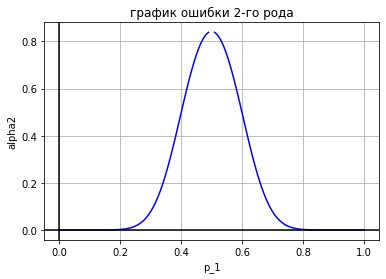

In [14]:
n = 50
p0 = 0.5
palt1 = np.linspace(0, 0.49, 100)
palt2 = np.linspace(0.51, 1, 100)
alpha2_1 = (sts.norm(0, 1)).cdf(2*np.sqrt(n)*(0.1 - palt1 + p0)) + (sts.norm(0, 1)).cdf(2*np.sqrt(n)*(0.1 + palt1 - p0)) - 1
alpha2_2 = (sts.norm(0, 1)).cdf(2*np.sqrt(n)*(0.1 - palt2 + p0)) + (sts.norm(0, 1)).cdf(2*np.sqrt(n)*(0.1 + palt2 - p0)) - 1
plt.plot(palt1, alpha2_1, color = 'b')
plt.plot(palt2, alpha2_2, color = 'b')
plt.grid(True)
plt.title('график ошибки 2-го рода')
plt.axvline(x = 0, color = 'k')
plt.axhline(y = 0, color = 'k')
plt.xlabel('p_1')
plt.ylabel('alpha2')